# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Dataset

In [2]:
dataset = pd.read_csv('dataset/Mall_Customers.csv')
dataset.loc[dataset['Spending Score (1-100)'] <= 25, 'Category'] = 'low'
dataset.loc[(dataset['Spending Score (1-100)'] > 25) & (dataset['Spending Score (1-100)'] <= 50), 'Category'] = 'medium'
dataset.loc[dataset['Spending Score (1-100)'] > 50, 'Category'] = 'high'
print(dataset.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Category'],
      dtype='object')


In [3]:
dataset = dataset[['Age', 'Annual Income (k$)', 'Category']]
print(dataset.columns)

Index(['Age', 'Annual Income (k$)', 'Category'], dtype='object')


In [4]:
X = dataset[['Age', 'Annual Income (k$)']].to_numpy(np.float32)
Y = dataset[['Category']].to_numpy()
print(X)
print(Y)

[[ 19.  15.]
 [ 21.  15.]
 [ 20.  16.]
 [ 23.  16.]
 [ 31.  17.]
 [ 22.  17.]
 [ 35.  18.]
 [ 23.  18.]
 [ 64.  19.]
 [ 30.  19.]
 [ 67.  19.]
 [ 35.  19.]
 [ 58.  20.]
 [ 24.  20.]
 [ 37.  20.]
 [ 22.  20.]
 [ 35.  21.]
 [ 20.  21.]
 [ 52.  23.]
 [ 35.  23.]
 [ 35.  24.]
 [ 25.  24.]
 [ 46.  25.]
 [ 31.  25.]
 [ 54.  28.]
 [ 29.  28.]
 [ 45.  28.]
 [ 35.  28.]
 [ 40.  29.]
 [ 23.  29.]
 [ 60.  30.]
 [ 21.  30.]
 [ 53.  33.]
 [ 18.  33.]
 [ 49.  33.]
 [ 21.  33.]
 [ 42.  34.]
 [ 30.  34.]
 [ 36.  37.]
 [ 20.  37.]
 [ 65.  38.]
 [ 24.  38.]
 [ 48.  39.]
 [ 31.  39.]
 [ 49.  39.]
 [ 24.  39.]
 [ 50.  40.]
 [ 27.  40.]
 [ 29.  40.]
 [ 31.  40.]
 [ 49.  42.]
 [ 33.  42.]
 [ 31.  43.]
 [ 59.  43.]
 [ 50.  43.]
 [ 47.  43.]
 [ 51.  44.]
 [ 69.  44.]
 [ 27.  46.]
 [ 53.  46.]
 [ 70.  46.]
 [ 19.  46.]
 [ 67.  47.]
 [ 54.  47.]
 [ 63.  48.]
 [ 18.  48.]
 [ 43.  48.]
 [ 68.  48.]
 [ 19.  48.]
 [ 32.  48.]
 [ 70.  49.]
 [ 47.  49.]
 [ 60.  50.]
 [ 60.  50.]
 [ 59.  54.]
 [ 26.  54.]
 [ 45.  54.]

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, train_size=0.9)
Y_train = np.ravel(Y_train)
Y_test = np.ravel(Y_test)
print(Y_train.shape, Y_test.shape)

(180,) (20,)


# Training and Testing

In [6]:
def run(k, metric, show_confusion_matrix=False):
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    model.fit(X_train, Y_train)
    
    Y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    
    if show_confusion_matrix:
        display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
        display_cm.plot()
        plt.show()
    
    return accuracy_score(Y_test, Y_pred)

## Plotting K vs Accuracy

In [7]:
def plot_k_vs_accuracy(metric: str):
    ks = list(range(5, 31, 2))
    accuracies = []
    for k in ks:
        result = run(k, metric)
        accuracies.append(result)
        
    plt.title(f'K vs Accuracy With {metric.upper()} Distance Metric')
    plt.plot(ks, accuracies)
    plt.xlabel('Neigbour Count (K)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

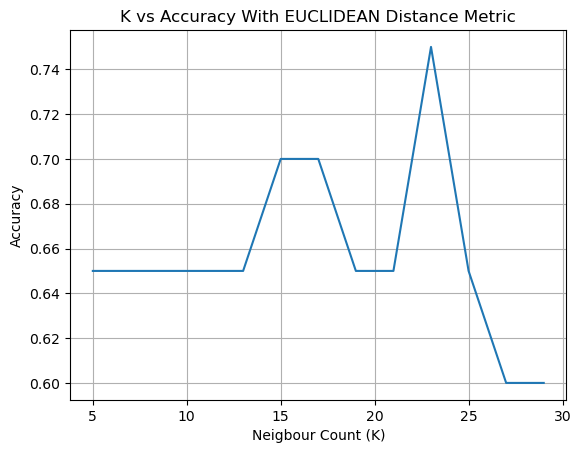

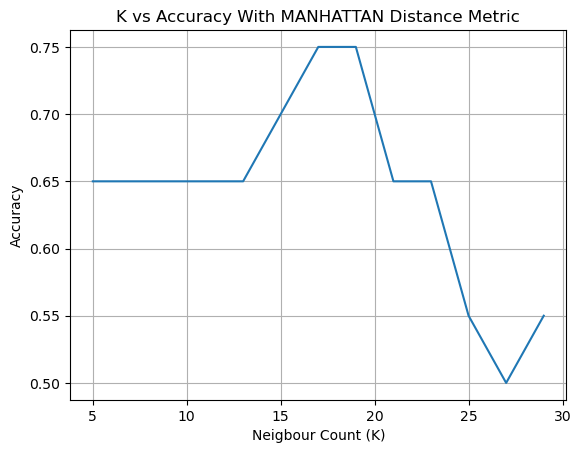

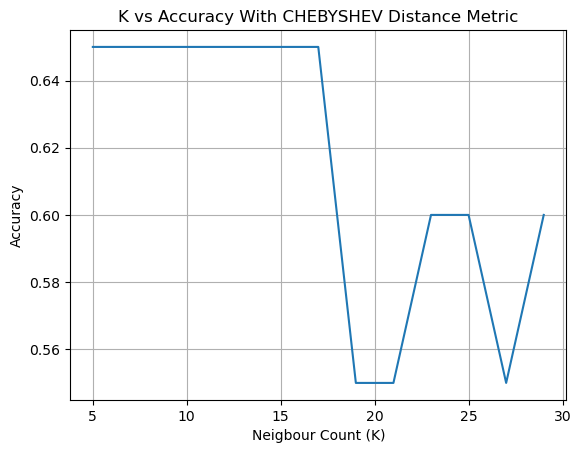

In [8]:
plot_k_vs_accuracy('euclidean')
plot_k_vs_accuracy('manhattan')
plot_k_vs_accuracy('chebyshev')

## Performance Difference With Different Metrics

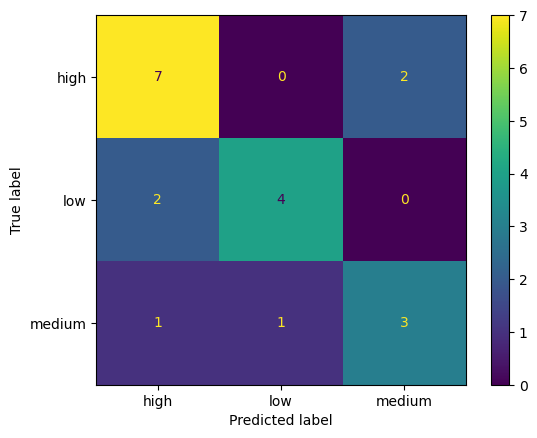

0.7

In [9]:
run(17, 'euclidean', True)

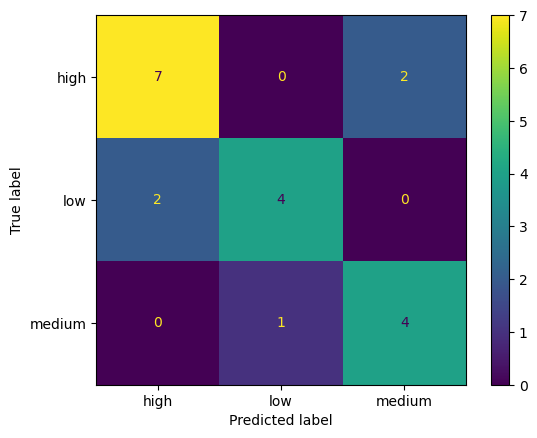

0.75

In [10]:
run(17, 'manhattan', True)

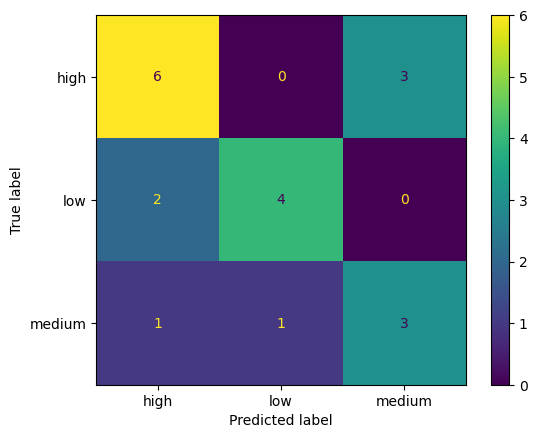

0.65

In [11]:
run(17, 'chebyshev', True)